# Real-data robustness study: one figure per property

Reads `results/real_robustness/` produced by

```bash
python run_real_data.py --study robustness --sweep all --seeds 0:50 --workers 12
python run_real_data.py --study robustness --ja          # JA-Ranking reanalysis (figure A, panel a)
python run_real_data.py --study robustness --clean-fit   # judge-level position effects (figure A, panel d)
```

Design: `code/plan/2026-09-06-real-data-robustness-plan.md`, Section 22. Metric: excess held-out human log loss over the test-pool BTL floor; bands are $\pm1.96$ Monte Carlo s.e. over seeds.
Methods: Human-only; Pooled-LLM + scale (no judge structure, no order term); Consensus-cal (rank-0 staged, $s=\alpha\widehat\mu$); DIAL-$\mu$ (rank 0, joint weighted likelihood, GACV weight); DIAL (rank and weight by GACV); DIAL-noDeb (DIAL without the order term).

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

REPO = Path.cwd().parent; sys.path.insert(0, str(REPO))
from experiments.real_data.robustness_plot import load, aggregate, aggregate_spectest
RESULTS = REPO / "results" / "real_robustness"; FIGURES = REPO / "figures"; FIGURES.mkdir(exist_ok=True)
DATASETS = ["arena_33k", "mt_bench", "pandalm"]; DLAB = {"arena_33k": "Chatbot Arena", "mt_bench": "MT-Bench", "pandalm": "PandaLM"}
# Shared method panel (experiments/style.py): five presented methods plus appendix diagnostics.
from experiments.style import PRESENTED, APPENDIX, LABEL as _LABEL, STYLE as _STYLE, INK, INK_SOFT, GRID
METHODS = list(PRESENTED)
LABEL = dict(_LABEL); LABEL["oracle_test"] = "test-oracle weight"
STYLE = dict(_STYLE); STYLE["oracle_test"] = dict(STYLE["oracle"])
mpl.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"], "font.size": 8, "axes.labelsize": 8.5,
                     "axes.titlesize": 9, "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7.5, "axes.edgecolor": INK_SOFT,
                     "axes.linewidth": 0.6, "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.dpi": 300, "figure.dpi": 130})

rows = {d: load(d, REPO) for d in DATASETS if (RESULTS / d / "rows.jsonl").exists()}
agg = {d: aggregate(df) for d, df in rows.items()}
spec = aggregate_spectest(rows["arena_33k"]) if "arena_33k" in rows else pd.DataFrame()
for d, df in rows.items():
    ok = df[(~df.failed) & (~df.method.isin(["spectest", "planner"]))]
    print(f"{DLAB[d]:<14} seeds={df.seed.nunique()}  rows={len(df)}  failed={int(df.failed.sum())}  non-converged={int((~ok.converged.fillna(True).astype(bool)).sum())}")
if any(rows[d].failed.any() for d in rows):
    print(pd.concat(rows.values())[lambda x: x.failed].groupby(["dataset", "sweep", "panel", "level", "method"]).size().to_string())

Chatbot Arena  seeds=50  rows=31080  failed=70  non-converged=2013
MT-Bench       seeds=50  rows=3450  failed=0  non-converged=7
PandaLM        seeds=50  rows=7849  failed=1  non-converged=94
dataset    sweep       panel    level   method       
arena_33k  llm_budget  all      500.0   dial_mu           1
                                        dial_nodeb       11
                                        dial_w            2
                                1000.0  consensus_cal     4
                                        dial_nodeb        5
                                        dial_w            5
                                2000.0  consensus_cal     2
                                        dial_w            2
           noise       biased5  4.0     consensus_cal     6
                                        dial_nodeb       17
                                        dial_w            6
                                8.0     consensus_cal     1
                                  

In [2]:
def curve(ax, a, sweep, panel, kind, methods, x="level", n_0_level=None, logx=False, hline_human=True, band=True):
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind)]
    if n_0_level is not None: g = g[g.n_0_level == n_0_level]
    if g.empty: ax.text(0.5, 0.5, "not run", ha="center", va="center", transform=ax.transAxes, color=INK_SOFT); return
    for m in methods:
        gm = g[g.method == m].copy()
        if gm.empty: continue
        gm["_x"] = gm["n_0_mean"] if x == "n_0" else gm["level"]
        gm = gm.sort_values("_x")
        xs = gm["_x"].to_numpy()
        y = gm["excess_mean"].to_numpy(); se = gm["excess_se"].to_numpy()
        st = dict(STYLE[m]); lw = st.pop("lw", 1.2); mk = st.pop("marker")
        if m == "human_only" and hline_human and x != "n_0":
            ax.axhline(y.mean(), color=st["color"], ls="-", lw=1.0, label=LABEL[m]); continue
        ax.plot(xs, y, lw=lw, marker=mk, ms=3.2, label=LABEL[m], **st)
        if band and m != "human_only": ax.fill_between(xs, y - 1.96 * se, y + 1.96 * se, color=st["color"], alpha=0.10, lw=0)
    if logx: ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5)

def clip_axis(ax, a, sweep, panel, kind, methods, n_0_level=None, top=None):
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind) & (a.method.isin(methods))]
    if n_0_level is not None: g = g[g.n_0_level == n_0_level]
    lo = g.excess_mean.min(); hi = g.excess_mean.max() if top is None else min(g.excess_mean.max(), lo + top)
    ax.set_ylim(lo - 0.15 * (hi - lo), hi + 0.1 * (hi - lo))

## Main-text figure: position bias (top row) and robustness / verification (bottom row)

Top: (a) HJA's JA-Ranking judge files, canonical model displayed first in every record and a 99% first-slot judge in the panel: Kendall $\tau$ of each consensus estimator with the human ranking (filled: all judges; hollow: GLM-4.5-Air removed). (b) Five position-biased judges with a canonical-first default order and a share $\rho_{\mathrm{swap}}$ of swapped copies, Arena, $n_0=300$. (c) The same five judges with balanced LLM rows subsampled to $n_L$ at $n_0=1{,}000$: Kendall $\tau$ of each estimator's ranking with the held-out human ranking; DIAL-$\mu$ re-estimates the consensus with the human comparisons and is never below the better of human-only and the two-step consensus calibration. (d) Judge-level position effects with cell-clustered 95% intervals against the model-free swap-inconsistency rate of Figure 1(b).
Bottom: (e, f) anti-consensus and position-only judges injected into the five-judge panel when its LLM judgments are scarce (2,000 balanced rows before injection, $n_0=1{,}000$), on Kendall $\tau$; the abundant-LLM log-loss version is the appendix figure below. (g) Specification test of $s_0=\alpha\mu$ against the human budget for English users, non-English users scored with the global consensus, and non-English users scored with a consensus refitted on non-English prompts; hollow markers: the unrestricted human-only MLE did not exist in every seed.

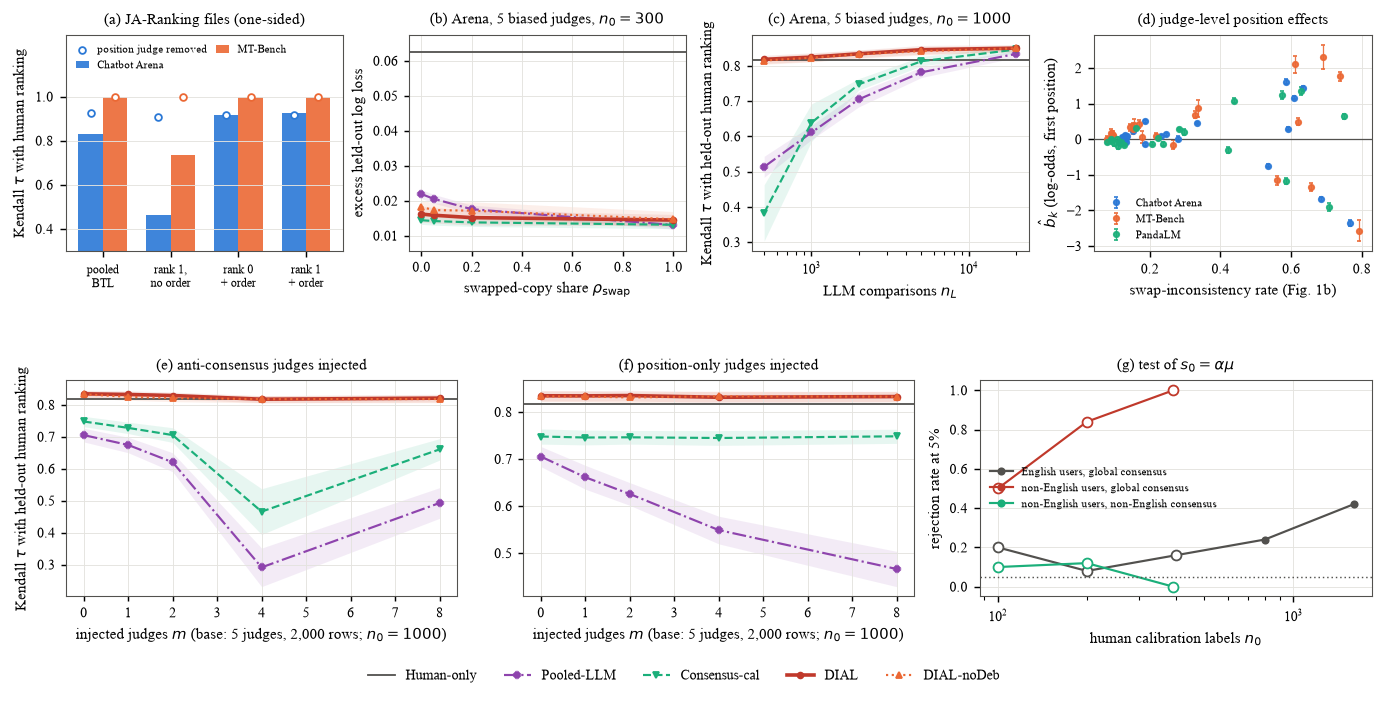

,kind,level,n,reject_rate,stat_mean,df,ho_exists,excess_restricted,excess_full,tau_mu,n_0
0,english_global,100.0,50,0.2,22.528,18.0,0.02,0.016,1.157,0.845,100
1,english_global,200.0,50,0.08,20.943,18.0,0.66,0.013,0.152,0.845,200
2,english_global,400.0,50,0.16,20.565,18.0,0.96,0.012,0.044,0.845,400
3,english_global,800.0,50,0.24,23.463,18.0,1.00,0.011,0.021,0.845,800
4,english_global,1600.0,50,0.42,28.073,18.0,1.00,0.011,0.014,0.845,1600
5,nonenglish_global,100.0,50,0.5,28.871,18.0,0.04,0.120,1.482,0.595,100
6,nonenglish_global,200.0,50,0.84,40.655,18.0,0.38,0.115,0.287,0.595,200
7,nonenglish_global,400.0,50,1.0,58.510,18.0,0.96,0.115,0.105,0.595,392
8,nonenglish_global,800.0,50,1.0,58.510,18.0,0.96,0.115,0.105,0.595,392
9,nonenglish_global,1600.0,50,1.0,58.510,18.0,0.96,0.115,0.105,0.595,392


In [3]:
fig = plt.figure(figsize=(10.8, 5.4))
gs = fig.add_gridspec(2, 12, height_ratios=[1, 1], hspace=0.6, wspace=1.35, left=0.06, right=0.99, top=0.94, bottom=0.14)
axA = [fig.add_subplot(gs[0, 0:3]), fig.add_subplot(gs[0, 3:6]), fig.add_subplot(gs[0, 6:9]), fig.add_subplot(gs[0, 9:12])]
axB = [fig.add_subplot(gs[1, 0:4]), fig.add_subplot(gs[1, 4:8]), fig.add_subplot(gs[1, 8:12])]
# (a) JA reanalysis
ja = json.load(open(RESULTS / "ja_reanalysis.json")) if (RESULTS / "ja_reanalysis.json").exists() else None
ax = axA[0]
if ja:
    t = pd.DataFrame(ja["consensus"]); meths = ["pooled BTL, no order term", "rank-1 consensus, no order term (HJA)", "rank-0 consensus + order term", "rank-1 consensus + order term"]
    short = ["pooled\nBTL", "rank 1,\nno order", "rank 0\n+ order", "rank 1\n+ order"]
    xs = np.arange(len(meths)); w = 0.36; col = {"arena_33k": "#2a78d6", "mt_bench": "#eb6834"}
    for n, d in enumerate(["arena_33k", "mt_bench"]):
        full = t[(t.dataset == d) & (t.variant == "all judges")].set_index("method").reindex(meths).tau
        wo = t[(t.dataset == d) & (t.variant.str.startswith("without"))].set_index("method").reindex(meths).tau
        ax.bar(xs + (n - 0.5) * w, full, w, color=col[d], alpha=0.9, label=DLAB[d])
        ax.scatter(xs + (n - 0.5) * w, wo, s=14, facecolors="white", edgecolors=col[d], zorder=3, label="position judge removed" if n == 0 else None)
    ax.set_xticks(xs); ax.set_xticklabels(short, fontsize=6.6); ax.set_ylim(0.3, 1.28); ax.set_yticks([0.4, 0.6, 0.8, 1.0]); ax.set_ylabel("Kendall $\\tau$ with human ranking")
    ax.set_title("(a) JA-Ranking files (one-sided)", fontsize=8.5); ax.legend(frameon=False, fontsize=6.0, loc="upper left", ncol=2, columnspacing=0.8, handlelength=1.2); ax.grid(True, axis="y", color=GRID, lw=0.5)
methods_A = list(PRESENTED)
ax = axA[1]
if "arena_33k" in agg: curve(ax, agg["arena_33k"], "order", "biased5", "none", methods_A); clip_axis(ax, agg["arena_33k"], "order", "biased5", "none", methods_A)
ax.set_xlabel("swapped-copy share $\\rho_{\\mathrm{swap}}$"); ax.set_title("(b) Arena, 5 biased judges, $n_0=300$", fontsize=8.5); ax.set_ylabel("excess held-out log loss")
# (c) LLM budget on Kendall tau: the regime in which the adaptive estimators beat the two-step consensus calibration
ax = axA[2]
if "arena_33k" in agg:
    g = agg["arena_33k"][(agg["arena_33k"].sweep == "llm_budget") & (agg["arena_33k"].panel == "biased5") & (agg["arena_33k"].n_0_level == 1000)]
    for m in PRESENTED:
        gm = g[g.method == m].sort_values("level"); st = dict(STYLE[m]); lw = st.pop("lw", 1.2); mk = st.pop("marker")
        if m == "human_only": ax.axhline(gm.ref_kendall_mean.mean(), color=st["color"], lw=1.0, label=LABEL[m]); continue
        ax.plot(gm.level, gm.ref_kendall_mean, lw=lw, marker=mk, ms=3.2, label=LABEL[m], **st)
        ax.fill_between(gm.level, gm.ref_kendall_mean - 1.96 * gm.ref_kendall_se, gm.ref_kendall_mean + 1.96 * gm.ref_kendall_se, color=st["color"], alpha=0.10, lw=0)
    ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter()); ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5)
ax.set_xlabel("LLM comparisons $n_L$"); ax.set_ylabel("Kendall $\\tau$ with held-out human ranking"); ax.set_title("(c) Arena, 5 biased judges, $n_0=1000$", fontsize=8.5)
ax = axA[3]; col3 = {"arena_33k": "#2a78d6", "mt_bench": "#eb6834", "pandalm": "#1baf7a"}
for d in DATASETS:
    cf = RESULTS / d / "clean_fit.json"; runs = sorted((REPO / "results" / "motivation").glob(f"{d}-*"))
    if not cf.exists() or not runs: continue
    f = json.load(open(cf)); mot = pd.read_csv(runs[-1] / "per_judge.csv").set_index("judge")
    x = np.array([mot.loc[j, "swap_inconsistency_rate"] if j in mot.index else np.nan for j in f["judges"]]); b = np.array(f["b"]); lo = np.array(f["b_lower"]); hi = np.array(f["b_upper"])
    ax.errorbar(x, b, yerr=[b - lo, hi - b], fmt="o", ms=3, lw=0.7, capsize=1.2, color=col3[d], label=DLAB[d], alpha=0.9)
ax.axhline(0, color=INK_SOFT, lw=0.7); ax.set_xlabel("swap-inconsistency rate (Fig. 1b)"); ax.set_ylabel("$\\hat b_k$ (log-odds, first position)"); ax.set_title("(d) judge-level position effects", fontsize=8.5)
ax.grid(True, color=GRID, lw=0.5); ax.legend(frameon=False, fontsize=6.2)
# bottom row
methods_B = list(PRESENTED)
def tau_curve(ax, a, sweep, panel, kind, methods, x="level"):
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind)]
    for m in methods:
        gm = g[g.method == m].sort_values("level"); st = dict(STYLE[m]); lw = st.pop("lw", 1.2); mk = st.pop("marker")
        if gm.empty: continue
        if m == "human_only": ax.axhline(gm.ref_kendall_mean.mean(), color=st["color"], lw=1.0, label=LABEL[m]); continue
        ax.plot(gm.level, gm.ref_kendall_mean, lw=lw, marker=mk, ms=3.2, label=LABEL[m], **st)
        ax.fill_between(gm.level, gm.ref_kendall_mean - 1.96 * gm.ref_kendall_se, gm.ref_kendall_mean + 1.96 * gm.ref_kendall_se, color=st["color"], alpha=0.10, lw=0)
    ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5)
for ax, kind, ttl in [(axB[0], "anti", "(e) anti-consensus judges injected"), (axB[1], "position", "(f) position-only judges injected")]:
    if "arena_33k" in agg: tau_curve(ax, agg["arena_33k"], "noise_scarce", "biased5", kind, methods_B)
    ax.set_xlabel("injected judges $m$ (base: 5 judges, 2,000 rows; $n_0=1000$)"); ax.set_title(ttl, fontsize=8.5)
axB[0].set_ylabel("Kendall $\\tau$ with held-out human ranking")
ax = axB[2]
if not spec.empty:
    scol = {"english_global": ("#52514e", "English users, global consensus"), "nonenglish_global": ("#c0392b", "non-English users, global consensus"), "nonenglish_subset": ("#1baf7a", "non-English users, non-English consensus")}
    for k, (c, lab) in scol.items():
        g = spec[spec.kind == k].sort_values("n_0").drop_duplicates("n_0")
        ax.plot(g.n_0, g.reject_rate, color=c, marker="o", ms=3.5, lw=1.2, label=lab)
        bad = g[g.ho_exists < 1]; ax.scatter(bad.n_0, bad.reject_rate, s=30, facecolors="white", edgecolors=c, zorder=3)
    ax.axhline(0.05, color=INK_SOFT, ls=(0, (1, 2)), lw=0.8); ax.set_xscale("log"); ax.set_ylim(-0.05, 1.05); ax.set_xlabel("human calibration labels $n_0$"); ax.set_ylabel("rejection rate at 5%")
    ax.set_title("(g) test of $s_0=\\alpha\\mu$", fontsize=8.5); ax.legend(frameon=False, fontsize=6.2, loc="center left"); ax.grid(True, color=GRID, lw=0.5)
h, l = axA[1].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=6, frameon=False, bbox_to_anchor=(0.5, 0.0))
fig.savefig(FIGURES / "fig_real_main.pdf", bbox_inches="tight"); plt.show()
if not spec.empty: display(spec.round(3))

## Appendix figure: injected judges with abundant LLM judgments

The same injection as the main figure's (e, f) but with all balanced judgments of the five judges (27,000 to 71,000 rows) and $n_0=300$, on excess held-out log loss and on Kendall $\tau$. With abundant LLM data the structured estimators absorb the injected judges equally and the adaptive weight has nothing to gain over the two-step consensus calibration; the pooled baseline degrades in both metrics.

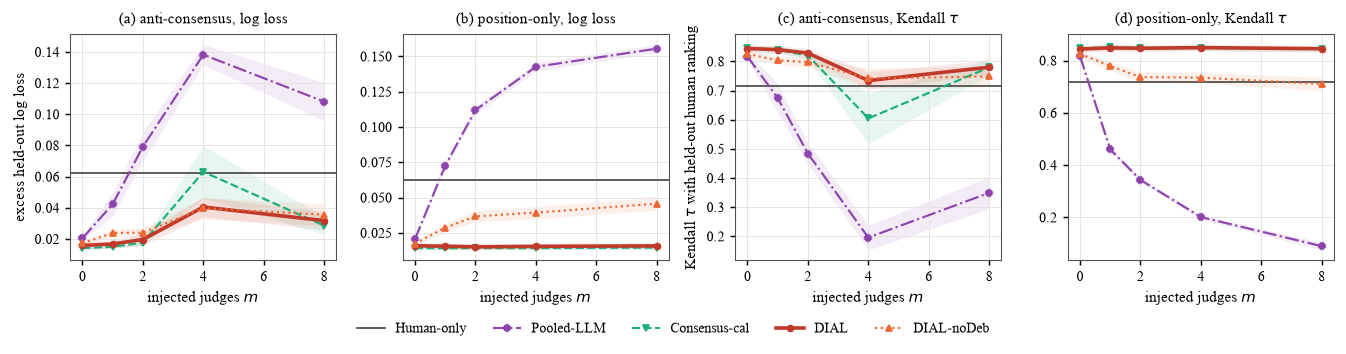

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(10.4, 2.5))
for ax, kind, ttl in [(axes[0], "anti", "(a) anti-consensus, log loss"), (axes[1], "position", "(b) position-only, log loss")]:
    if "arena_33k" in agg: curve(ax, agg["arena_33k"], "noise", "biased5", kind, methods_B)
    ax.set_xlabel("injected judges $m$"); ax.set_title(ttl, fontsize=8.5)
axes[0].set_ylabel("excess held-out log loss")
for ax, kind, ttl in [(axes[2], "anti", "(c) anti-consensus, Kendall $\\tau$"), (axes[3], "position", "(d) position-only, Kendall $\\tau$")]:
    if "arena_33k" in agg: tau_curve(ax, agg["arena_33k"], "noise", "biased5", kind, methods_B)
    ax.set_xlabel("injected judges $m$"); ax.set_title(ttl, fontsize=8.5)
axes[2].set_ylabel("Kendall $\\tau$ with held-out human ranking")
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_noise_abundant.pdf", bbox_inches="tight"); plt.show()

## Appendix figure: human-record efficiency

Top: human budget with the as-collected balanced LLM data (all 21 judges); the LLM-anchored estimators sit at the LLM floor from a few hundred labels while human-only needs the full pool. Human-only is off the chart at the smallest budgets, where its MLE does not exist.
Bottom: LLM rows subsampled to $n_L$ at fixed human budgets on Arena; with ten or fewer judgments per pair the joint estimators (DIAL-$\mu$, DIAL) beat both the staged consensus and human-only. Dotted: the weight minimizing the test log loss.

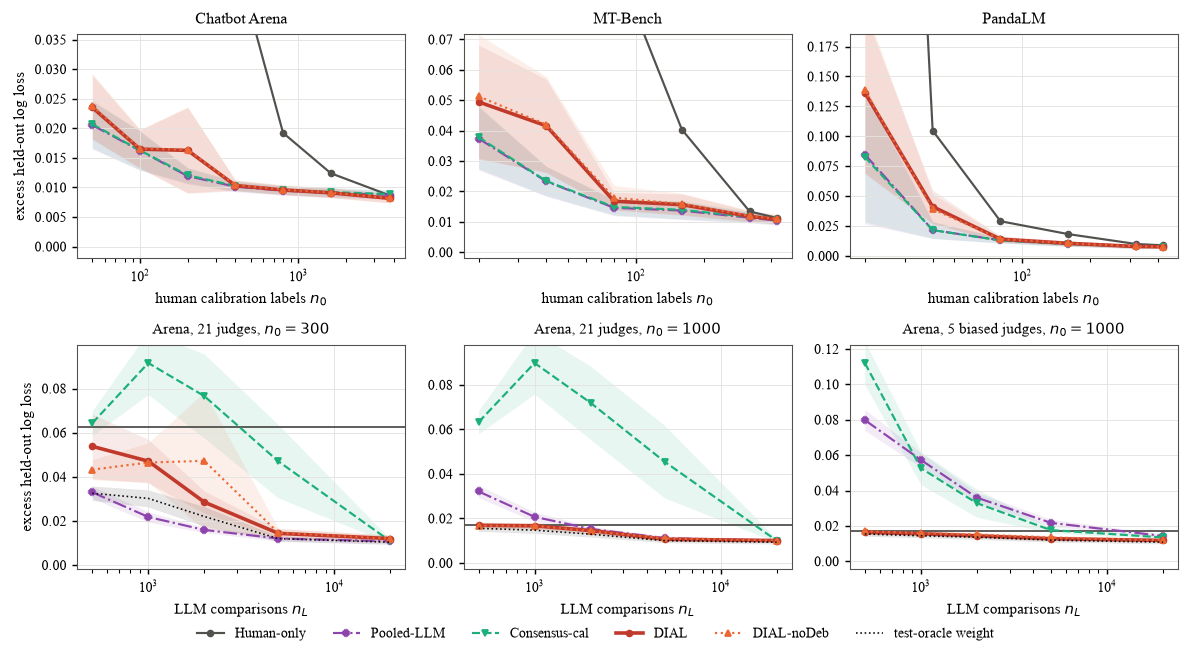

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(9.2, 4.9))
methods_C1 = list(PRESENTED)
for ax, d in zip(axes[0], DATASETS):
    if d in agg:
        curve(ax, agg[d], "budget", "all", "none", methods_C1, x="n_0", logx=True, hline_human=False)
        g = agg[d][(agg[d].sweep == "budget") & (agg[d].method != "human_only") & (agg[d].method.isin(methods_C1))]
        ax.set_ylim(min(g.excess_mean.min(), g.floor.mean() * 0) - 0.002, g.excess_mean.max() * 1.3 + 0.005)
    ax.set_title(DLAB[d]); ax.set_xlabel("human calibration labels $n_0$")
axes[0, 0].set_ylabel("excess held-out log loss")
methods_C2 = list(PRESENTED) + ["oracle_test"]
for ax, (panel, n0, ttl) in zip(axes[1], [("all", 300, "Arena, 21 judges, $n_0=300$"), ("all", 1000, "Arena, 21 judges, $n_0=1000$"), ("biased5", 1000, "Arena, 5 biased judges, $n_0=1000$")]):
    if "arena_33k" in agg:
        curve(ax, agg["arena_33k"], "llm_budget", panel, "none", methods_C2, n_0_level=n0, logx=True); clip_axis(ax, agg["arena_33k"], "llm_budget", panel, "none", methods_C2, n_0_level=n0)
    ax.set_title(ttl, fontsize=8.5); ax.set_xlabel("LLM comparisons $n_L$")
axes[1, 0].set_ylabel("excess held-out log loss")
h1, l1 = axes[0, 0].get_legend_handles_labels(); h2, l2 = axes[1, 0].get_legend_handles_labels()
seen = {}; [seen.setdefault(l, h) for h, l in list(zip(h1, l1)) + list(zip(h2, l2))]
fig.legend(list(seen.values()), list(seen.keys()), loc="lower center", ncol=8, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_efficiency.pdf", bbox_inches="tight"); plt.show()

## Appendix figure: budget planning from a pilot

From a pilot of $n_{\mathrm{pilot}}$ human labels, the specification-test statistic $T$ gives the point estimate $\widehat\Delta = \max\{0, (T - \mathrm{df})/(2n_{\mathrm{pilot}})\}$ and, by inverting the noncentral $\chi^2_{\mathrm{df}}$ distribution of $T$, a two-sided 90% interval $[\widehat\Delta_{\mathrm{lo}}, \widehat\Delta_{\mathrm{hi}}]$ for the anchor's misspecification $\Delta_W$.
Predicted excess (relative to the in-sample test-pool floor, whose optimism $(N-1)/(2n_{\mathrm{test}})$ is added back): anchored $\Delta + (r+1)/(2n)$ at the point estimate (line) and at the two interval ends (band); human-only $(N-1)/(2n)$; the crossover $n^\star=(N-r-2)/(2\Delta)$ is drawn at the point estimate (dashed) and as the interval implied by $[\widehat\Delta_{\mathrm{lo}}, \widehat\Delta_{\mathrm{hi}}]$ (grey span, open to the right when the lower end is zero).
All quantities are medians over the 50 pilots; the mean gives interval ends within 0.002 of the median ends, so the choice of aggregate no longer matters once the interval replaces the point estimate.
Observed curves are the 50-seed `budget` sweep (Consensus-cal and human-only).

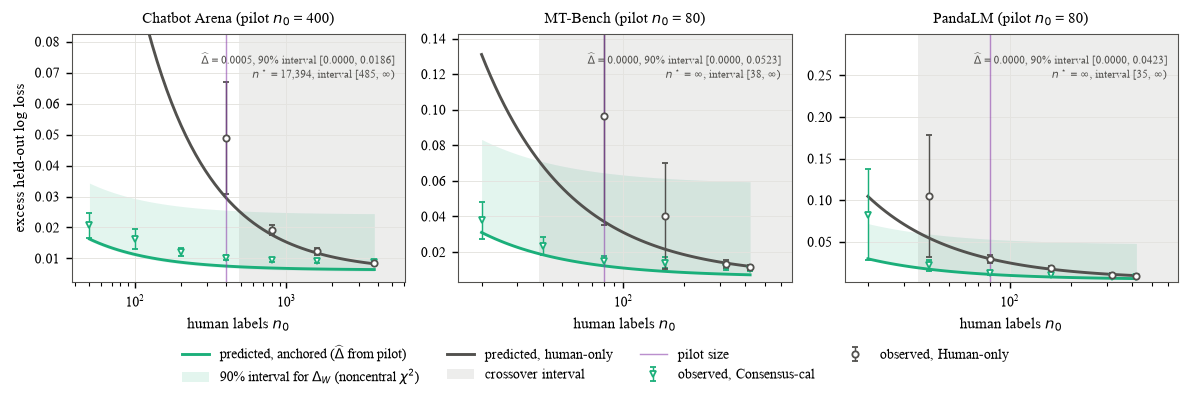

,dataset,n_pilot,delta_hat_median,delta_lo_median,delta_hi_median,delta_hat_mean,delta_lo_mean,delta_hi_mean,delta_all_train,n_star_point,n_star_interval_lo,n_star_interval_hi,n_star_observed,share_pilots_delta_zero,share_pilots_interval_lo_zero,coverage_of_fullpool
0,Chatbot Arena,400,0.0005,0.0,0.0186,0.0043,0.0005,0.0197,0.0013,17394.0757,484.8452,inf,3556.8511,0.46,0.88,0.88
1,MT-Bench,80,0.0000,0.0,0.0523,0.0065,0.0003,0.0542,0.0000,inf,38.2414,inf,NaN,0.54,0.96,0.96
2,PandaLM,80,0.0000,0.0,0.0423,0.0038,0.0001,0.0433,0.0000,inf,35.4775,inf,NaN,0.64,0.98,0.98


,dataset,n_pilot,delta_hat_median,delta_hat_q10,delta_hat_q90,n_star_median,labels_to_eps_anchored_median,labels_to_eps_human_only,eps
0,Chatbot Arena,100,0.0171,0.0,0.0470,410.1687,inf,950.0,0.01
1,Chatbot Arena,200,0.0058,0.0,0.0361,724.5055,120.4057,950.0,0.01
2,Chatbot Arena,400,0.0005,0.0,0.0140,1648.8709,52.7817,950.0,0.01
3,MT-Bench,40,0.0105,0.0,0.0551,64.0439,inf,250.0,0.01
4,MT-Bench,80,0.0000,0.0,0.0210,208.4971,50.0000,250.0,0.01
5,MT-Bench,160,0.0000,0.0,0.0183,186.6898,50.0000,250.0,0.01
6,PandaLM,40,0.0000,0.0,0.0622,45.4733,50.0000,200.0,0.01
7,PandaLM,80,0.0000,0.0,0.0148,212.0522,50.0000,200.0,0.01
8,PandaLM,160,0.0000,0.0,0.0089,272.8127,50.0000,200.0,0.01


In [6]:
from experiments.real_data.robustness_plot import planner_frame, predicted_curves, planner_with_intervals
PILOT = {"arena_33k": 400, "mt_bench": 80, "pandalm": 80}
fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.7))
summary_rows = []
for ax, d in zip(axes, DATASETS):
    if d not in rows: continue
    pl = planner_with_intervals(planner_frame(rows[d])); obs = agg[d][(agg[d].sweep == "budget")]
    if pl.empty or obs.empty: ax.set_title(DLAB[d]); continue
    grid = np.geomspace(obs.n_0_mean.min(), obs.n_0_mean.max(), 60)
    pil = pl[pl.level == PILOT[d]]
    # point estimate and 90% interval for Delta_W, each summarized by the median over pilots
    d_med, d_lo, d_hi = float(pil.delta_hat.median()), float(pil.delta_lo.median()), float(pil.delta_hi.median())
    med = pil.iloc[0].copy(); med["delta_hat"] = d_med
    N_, r_ = med["N"], med["r"]; xr = grid.max() * 1.6
    pa_med, ph_med = predicted_curves(med, grid)
    lo_row = med.copy(); lo_row["delta_hat"] = d_lo; hi_row = med.copy(); hi_row["delta_hat"] = d_hi
    pa_lo, _ = predicted_curves(lo_row, grid); pa_hi, _ = predicted_curves(hi_row, grid)
    ax.plot(grid, pa_med, color=STYLE["consensus_cal"]["color"], lw=1.6, label="predicted, anchored ($\\widehat\\Delta$ from pilot)")
    ax.fill_between(grid, pa_lo, pa_hi, color=STYLE["consensus_cal"]["color"], alpha=0.12, lw=0, label="90% interval for $\\Delta_W$ (noncentral $\\chi^2$)")
    ax.plot(grid, ph_med, color=STYLE["human_only"]["color"], lw=1.6, label="predicted, human-only")
    n_hi = (N_ - r_ - 2) / (2 * d_hi) if d_hi > 0 else np.inf          # earliest crossover compatible with the interval
    n_lo = (N_ - r_ - 2) / (2 * d_lo) if d_lo > 0 else np.inf          # latest (inf when Delta = 0 is not excluded)
    ax.axvspan(n_hi, min(n_lo, xr), color=INK_SOFT, alpha=0.10, lw=0, label="crossover interval")
    for m, mk in (("consensus_cal", "v"), ("human_only", "o")):
        g = obs[obs.method == m].sort_values("n_0_mean")
        ax.errorbar(g.n_0_mean, g.excess_mean, yerr=1.96 * g.excess_se, fmt=mk, ms=3.5, color=STYLE[m]["color"], lw=0.8, capsize=1.5, label=f"observed, {LABEL[m]}", mfc="white")
    # crossovers
    zero_share = float((pil.delta_hat == 0).mean())
    n_star_pred = (N_ - r_ - 2) / (2 * d_med) if d_med > 0 else np.inf          # crossover of the two drawn curves
    if np.isfinite(n_star_pred) and n_star_pred <= xr: ax.axvline(n_star_pred, color=INK_SOFT, ls="--", lw=0.9, label="predicted crossover $n^\\star$")
    txt = f"$\\widehat\\Delta$ = {d_med:.4f}, 90% interval [{d_lo:.4f}, {d_hi:.4f}]\n$n^\\star$ " + (f"= {n_star_pred:,.0f}" if np.isfinite(n_star_pred) else "= $\\infty$") + f", interval [{n_hi:,.0f}, " + (f"{n_lo:,.0f}]" if np.isfinite(n_lo) else "$\\infty$)")
    ax.text(0.97, 0.93, txt, ha="right", va="top", transform=ax.transAxes, fontsize=6.3, color=INK_SOFT)
    ax.set_xlim(grid.min() / 1.3, xr)
    gc = obs[obs.method == "consensus_cal"].set_index("n_0_mean").excess_mean.sort_index(); gh = obs[obs.method == "human_only"].set_index("n_0_mean").excess_mean.sort_index()
    diff = (gh - gc).dropna(); n_obs = np.nan
    for (x0, y0), (x1, y1) in zip(list(diff.items())[:-1], list(diff.items())[1:]):
        if y0 > 0 >= y1 or y0 >= 0 > y1: n_obs = np.exp(np.interp(0, [y1, y0], [np.log(x1), np.log(x0)])); break
    ax.axvline(PILOT[d], color="#8e44ad", lw=0.8, alpha=0.6, label="pilot size")
    lo = min(pa_med.min(), obs.excess_mean[obs.method == "consensus_cal"].min()); ax.set_ylim(lo - 0.004, 3.5 * obs.excess_mean[obs.method == "consensus_cal"].max() + 0.01)
    ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter()); ax.set_xlabel("human labels $n_0$"); ax.set_title(f"{DLAB[d]} (pilot $n_0$ = {PILOT[d]})", fontsize=8.5); ax.grid(True, color=GRID, lw=0.5)
    summary_rows.append(dict(dataset=DLAB[d], n_pilot=PILOT[d], delta_hat_median=d_med, delta_lo_median=d_lo, delta_hi_median=d_hi, delta_hat_mean=float(pil.delta_hat.mean()), delta_lo_mean=float(pil.delta_lo.mean()), delta_hi_mean=float(pil.delta_hi.mean()),
                             delta_all_train=float(pl.delta_all.median()), n_star_point=float(n_star_pred), n_star_interval_lo=float(n_hi), n_star_interval_hi=float(n_lo), n_star_observed=float(n_obs),
                             share_pilots_delta_zero=zero_share, share_pilots_interval_lo_zero=float((pil.delta_lo == 0).mean()), coverage_of_fullpool=float(((pil.delta_lo <= pil.delta_all) & (pil.delta_all <= pil.delta_hi)).mean())))
axes[0].set_ylabel("excess held-out log loss")
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.14))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_planner.pdf", bbox_inches="tight"); plt.show()
planner_summary = pd.DataFrame(summary_rows); display(planner_summary.round(4))
# sensitivity to the pilot size and budgets to reach a target
tab = []
for d in rows:
    pl = planner_frame(rows[d])
    for n_p, g in pl.groupby("level"):
        eps = 0.01
        n_anchor = np.where(g.delta_hat < eps, (g.r + 1) / (2 * (eps - g.delta_hat)), np.inf)
        tab.append(dict(dataset=DLAB[d], n_pilot=int(n_p), delta_hat_median=g.delta_hat.median(), delta_hat_q10=g.delta_hat.quantile(0.1), delta_hat_q90=g.delta_hat.quantile(0.9),
                        n_star_median=np.nanmedian(g.n_star.replace(np.inf, np.nan)), labels_to_eps_anchored_median=float(np.nanmedian(n_anchor)), labels_to_eps_human_only=float(((g.N - 1) / (2 * eps)).iloc[0]), eps=eps))
pd.set_option("display.width", 250); display(pd.DataFrame(tab).round(4))

## Appendix figure: W-calibration and weight diagnostics

(a, b) DIAL against DIAL-W (calibration within $W=[\mu,V]$ at the same LLM rank) and the fixed-weight fits, on the LLM-budget sweep (five biased judges, $n_0=1{,}000$) and under injected anti-consensus judges in the scarce regime, Kendall $\tau$. (c) Share of seeds in which DIAL's GACV weight sits at each endpoint, and the median finite relative weight, against $n_L$.

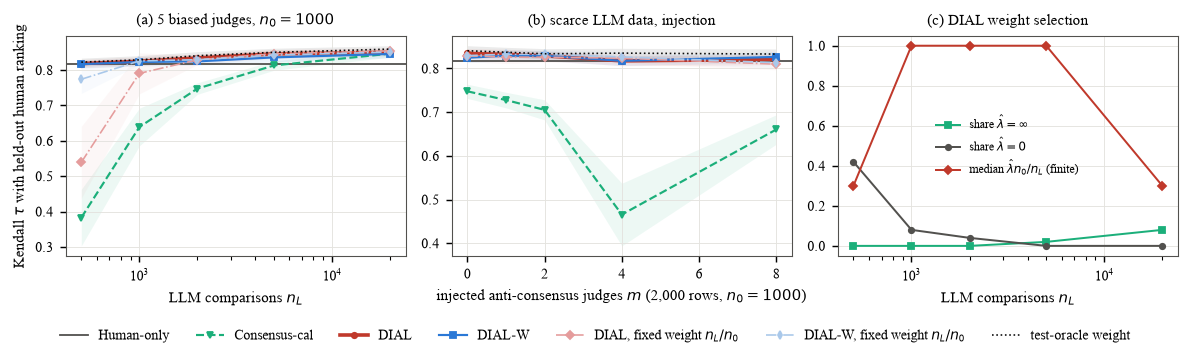

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.5))
diag = ["human_only", "consensus_cal", "dial_mu", "dial_w", "dial_mle_mu", "dial_mle_w", "oracle_test"]
def tau_lines(ax, g, methods, label=True):
    for m in methods:
        gm = g[g.method == m].sort_values("level"); st = dict(STYLE[m]); lw = st.pop("lw", 1.2); mk = st.pop("marker", None)
        if gm.empty: continue
        if m == "human_only": ax.axhline(gm.ref_kendall_mean.mean(), color=st["color"], lw=1.0, label=LABEL[m] if label else None); continue
        ax.plot(gm.level, gm.ref_kendall_mean, lw=lw, marker=mk, ms=3, label=LABEL[m] if label else None, **st)
        ax.fill_between(gm.level, gm.ref_kendall_mean - 1.96 * gm.ref_kendall_se, gm.ref_kendall_mean + 1.96 * gm.ref_kendall_se, color=st["color"], alpha=0.08, lw=0)
if "arena_33k" in agg:
    a = agg["arena_33k"]
    tau_lines(axes[0], a[(a.sweep == "llm_budget") & (a.panel == "biased5") & (a.n_0_level == 1000)], diag)
    axes[0].set_xscale("log"); axes[0].set_xlabel("LLM comparisons $n_L$"); axes[0].set_ylabel("Kendall $\\tau$ with held-out human ranking"); axes[0].set_title("(a) 5 biased judges, $n_0=1000$", fontsize=8.5)
    tau_lines(axes[1], a[(a.sweep == "noise_scarce") & (a.panel == "biased5") & (a.kind == "anti")], diag, label=False)
    axes[1].set_xlabel("injected anti-consensus judges $m$ (2,000 rows, $n_0=1000$)"); axes[1].set_title("(b) scarce LLM data, injection", fontsize=8.5)
    g = a[(a.sweep == "llm_budget") & (a.panel == "biased5") & (a.n_0_level == 1000) & (a.method == "dial_mu")].sort_values("level")
    axes[2].plot(g.level, g.lam_inf_frac, marker="s", ms=3, lw=1.1, color=STYLE["consensus_cal"]["color"], label="share $\\hat\\lambda=\\infty$")
    axes[2].plot(g.level, g.lam_zero_frac, marker="o", ms=3, lw=1.1, color=STYLE["human_only"]["color"], label="share $\\hat\\lambda=0$")
    axes[2].plot(g.level, g.lam_rel_med.fillna(0), marker="D", ms=3, lw=1.1, color=STYLE["dial_mu"]["color"], label="median $\\hat\\lambda n_0/n_L$ (finite)")
    axes[2].set_xscale("log"); axes[2].set_xlabel("LLM comparisons $n_L$"); axes[2].set_title("(c) DIAL weight selection", fontsize=8.5); axes[2].legend(frameon=False, fontsize=6.5)
for ax in axes: ax.grid(True, color=GRID, lw=0.5)
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=7, frameon=False, bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_diagnostics.pdf", bbox_inches="tight"); plt.show()

## Tables behind the figures

In [8]:
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
for d in agg:
    for (sw, pn, kd), g in agg[d].groupby(["sweep", "panel", "kind"]):
        piv = g.pivot_table(index=["level", "n_0_level"], columns="method", values="excess_mean").reindex(columns=list(PRESENTED) + ["dial_w", "staged_w", "dial_mle_mu", "dial_mle_w", "oracle_test", "dial_rsel"])
        print(f"=== {DLAB[d]} | {sw} | panel={pn} | kind={kd}  (excess held-out log loss, mean over {int(g.n.max())} seeds)"); print(piv.round(4).to_string()); print()

=== Chatbot Arena | budget | panel=all | kind=none  (excess held-out log loss, mean over 50 seeds)
method             human_only  pooled_cal  consensus_cal  dial_mu  dial_nodeb  dial_w  staged_w  dial_mle_mu  dial_mle_w  oracle_test  dial_rsel
level   n_0_level                                                                                                                               
-1.0    -1             0.0086      0.0087         0.0089   0.0081      0.0082  0.0087    0.0090       0.0088      0.0089       0.0075     0.0085
 50.0   -1             6.6515      0.0205         0.0207   0.0235      0.0238  0.0464    0.0443       0.0207      0.0472       0.0201     0.0679
 100.0  -1             1.0170      0.0162         0.0163   0.0165      0.0166  0.0283    0.0213       0.0163      0.0216       0.0156     0.0228
 200.0  -1             0.2220      0.0119         0.0121   0.0163      0.0164  0.0253    0.0146       0.0121      0.0148       0.0116     0.0163
 400.0  -1             0.0489  